# Station-MAE — Test Results

Five analyses, all computed from the saved `predictions.pt` dumps (full sliding test set):

1. **Effect of masking** — mr0.50 vs mr0.00 on the *masked* stations (v9, v11)
2. **Model comparison vs persistence** — per-variable, per lead-time (mr0.50)
3. **Terrain** — valley vs mountainous stations
4. **Per-station × variable × season** — which stations work and which don't

Errors are in **physical units** (per-station training σ). Files are ~1.6 GB each, so
§0 aggregates one run at a time and keeps only small summary tables — the raw arrays
are never all in memory at once.

**5. Predicted uncertainty** — for NLL models only (v9). The decoder emits a per-(horizon, station, variable) log σ² alongside the mean, so we can ask whether the model *knows* when it is wrong.


In [1]:
# ── Config ───────────────────────────────────────────────────────────────────
import os, sys, glob, datetime
import numpy as np, pandas as pd, matplotlib.pyplot as plt
# ── Project bootstrap ────────────────────────────────────────────────────────
# This notebook lives in notebooks/ but reads checkpoints/, test_results/ and
# report/ from the project root, and imports data/engine/model from src/.
# Re-running this cell is safe (it only climbs out of notebooks/ once).
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
PROJ = os.getcwd()
if os.path.join(PROJ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(PROJ, "src"))

RESULTS_ROOT = "test_results"
EXCLUDE      = ["PFA"]
CHUNK        = 2000          # windows processed at a time (memory control)

# Terrain split (§3) — a station is "mountain" if it is high OR steep.
ALT_THRESH   = 1000.0        # m
SLOPE_THRESH = 7.0           # SLOPE_2000M_SIGRATIO1

# Metric shown in the PLOTS below. Tables always report MAE, MSE and RMSE.
#   MAE  = mean |error|      — robust, same units as the variable
#   MSE  = mean error²       — SQUARED units; penalises large errors quadratically
#   RMSE = sqrt(MSE)         — back in the variable's own units
# MSE/RMSE are the ones to quote when large errors matter more than typical
# ones; MAE is the one to quote when they do not. They can rank models
# differently, which is itself worth reporting.
METRIC = "MAE"          # ← "MAE" | "MSE" | "RMSE"

VARS   = ["temperature", "pressure", "humidity", "wind_u", "wind_v"]
UNITS  = {"temperature":"°C","pressure":"hPa","humidity":"%","wind_u":"m/s","wind_v":"m/s"}
SEASONS = ["DJF","MAM","JJA","SON"]
COLORS = {"v9":"#2E7D8C","v11":"#D9663D","lstm-baseline-v1":"#6A4C93","persistence":"#444444"}

_CAND = ["/home/renku/work/PeakWeatherDataset",
         os.path.expanduser("~/Documents/ETH/_DAS Project/PeakWeatherDataset"),
         os.path.expanduser("~/PeakWeatherDataset"), "PeakWeatherDataset"]
DATA_ROOT = next((p for p in _CAND if os.path.isdir(p)), _CAND[-1])
plt.rcParams.update({"figure.dpi":110, "font.size":10})

# discover available runs: {run: {mask_ratio: path}}
RUNS = {}
for p in sorted(glob.glob(os.path.join(RESULTS_ROOT, "*", "best_mr*", "predictions.pt"))):
    run = p.split(os.sep)[-3]; mr = p.split(os.sep)[-2].replace("best_", "")
    RUNS.setdefault(run, {})[mr] = p
for r, d in RUNS.items():
    print(f"{r:20s} {sorted(d)}")

lstm-baseline-v1     ['mr0.00']
v13                  ['mr0.00', 'mr0.50']


In [2]:
# ── Station metadata: physical scale + terrain class ─────────────────────────
from data.dataset import load_peakweather, StationMAEDataset, compute_obs_stats
ds   = load_peakweather(root=DATA_ROOT)
keep = StationMAEDataset._resolve_keep_indices(ds, EXCLUDE)
STN  = [ds.stations_table.index[i] for i in keep]          # station ids, prediction order
N    = len(STN)

# per-(station, variable) training σ → physical units
_st   = compute_obs_stats(ds, train_years=None, per_station=True)
STD   = np.clip(_st["std"].numpy()[keep][:, :5], 1e-6, None)          # (N, 5)

# terrain
_t     = ds.stations_table.loc[STN]
alt    = _t["station_height"].astype(float).values
slope  = _t["SLOPE_2000M_SIGRATIO1"].astype(float).values
IS_MTN = (alt >= ALT_THRESH) | (slope >= SLOPE_THRESH)                # (N,) bool

# Guard: the station axis of the dumps must match this station list exactly.
# (load_peakweather drops stations lacking the requested parameters, so the raw
#  stations table is larger than the modelled network — never index it directly.)
import torch as _t
_probe = _t.load(next(iter(next(iter(RUNS.values())).values())),
                 map_location="cpu", weights_only=False)["preds"].shape[2]
assert _probe == N, (f"station mismatch: predictions have {_probe} stations but the "
                     f"dataset resolved {N}. Check EXCLUDE={EXCLUDE}.")
del _probe

print(f"stations: {N}   mountain: {IS_MTN.sum()}   valley: {(~IS_MTN).sum()}")
print(f"  mountain: alt {alt[IS_MTN].mean():.0f} m, slope {slope[IS_MTN].mean():.1f}")
print(f"  valley  : alt {alt[~IS_MTN].mean():.0f} m, slope {slope[~IS_MTN].mean():.1f}")

stations: 155   mountain: 74   valley: 81
  mountain: alt 1620 m, slope 8.5
  valley  : alt 540 m, slope 2.0


## 0. Aggregation pass

Each dump is streamed in chunks; we accumulate absolute-error sums and counts at the
granularity every later section needs, then release the arrays. **Persistence** is
derived from the same file (`targets[:, 0]` = the last observation carried forward),
so it sits on identical windows and masks.

In [3]:
# ── Stream each run and accumulate summary tables ────────────────────────────
import torch

def _season_idx(hours):                     # hours since epoch → 0..3
    ep = datetime.datetime(1970,1,1)
    m  = np.array([(ep + datetime.timedelta(hours=float(h))).month for h in hours.ravel()])
    s  = np.select([np.isin(m,[12,1,2]), np.isin(m,[3,4,5]), np.isin(m,[6,7,8])], [0,1,2], 3)
    return s.reshape(hours.shape)

def aggregate(path):
    """Return dicts of summed |err| and counts at several granularities."""
    d = torch.load(path, map_location="cpu", weights_only=False)
    P, T, M = d["preds"], d["targets"], d["masks"]
    TH, MI  = d["target_hours"], d.get("masked_idx")
    Mw, K   = P.shape[0], P.shape[1]
    # Sigma|e| under each key, and Sigma e^2 under key + "_sq", so MAE, MSE and
    # RMSE all come from one streaming pass over the dump.
    _shapes = {
        "kv":(K,len(VARS)), "kv_p":(K,len(VARS)),          # per horizon (model, persistence)
        "kv_m":(K,len(VARS)), "kv_m_p":(K,len(VARS)),      # per horizon, MASKED stations only
        "sv":(N,len(VARS)), "svs":(N,len(VARS),4),          # per station / station×season
    }
    A = {k: np.zeros(sh) for k, sh in _shapes.items()}
    A.update({k + "_sq": np.zeros(sh) for k, sh in _shapes.items()})
    C = {k: np.zeros(sh) for k, sh in {
        "kv":(K,len(VARS)), "kv_m":(K,len(VARS)),
        "sv":(N,len(VARS)), "svs":(N,len(VARS),4)}.items()}

    for a in range(0, Mw, CHUNK):
        b   = min(a+CHUNK, Mw)
        p   = P[a:b].numpy(); t = T[a:b,:,:,:5].numpy(); m = M[a:b,:,:,:5].numpy() > 0.5
        err = np.abs(p - t) * STD[None,None,:,:]                     # (c,K,N,V) physical
        t0  = T[a:b,0:1,:,:5].numpy()                                # persistence prediction
        m0  = M[a:b,0:1,:,:5].numpy() > 0.5
        errp= np.abs(t0 - t) * STD[None,None,:,:]
        mp  = m & m0                                                 # valid at Δ0 AND horizon
        sea = _season_idx(TH[a:b].numpy())                           # (c,K)

        e2, ep2 = err**2, errp**2
        A["kv"]      += (err *m ).sum(axis=(0,2));  C["kv"] += m.sum(axis=(0,2))
        A["kv_sq"]   += (e2  *m ).sum(axis=(0,2))
        A["kv_p"]    += (errp*mp).sum(axis=(0,2))
        A["kv_p_sq"] += (ep2 *mp).sum(axis=(0,2))
        C["kv_m"] += 0  # filled below only if masking present

        if MI is not None and MI.shape[1] > 0:                       # masked-station subset
            mi  = MI[a:b].numpy()
            sel = np.zeros((b-a, N), bool)
            np.put_along_axis(sel, mi, True, axis=1)
            sm  = m  & sel[:,None,:,None]
            smp = mp & sel[:,None,:,None]
            A["kv_m"]      += (err *sm ).sum(axis=(0,2)); C["kv_m"] += sm.sum(axis=(0,2))
            A["kv_m_sq"]   += (e2  *sm ).sum(axis=(0,2))
            A["kv_m_p"]    += (errp*smp).sum(axis=(0,2))
            A["kv_m_p_sq"] += (ep2 *smp).sum(axis=(0,2))

        A["sv"]    += (err*m).sum(axis=(0,1)); C["sv"] += m.sum(axis=(0,1))
        A["sv_sq"] += (e2 *m).sum(axis=(0,1))
        for si in range(4):                                          # station × season
            w = (sea == si)                                          # (c,K)
            if not w.any(): continue
            ww = w[:,:,None,None]
            A["svs"][:,:,si]    += (err*m*ww).sum(axis=(0,1))
            A["svs_sq"][:,:,si] += (e2 *m*ww).sum(axis=(0,1))
            C["svs"][:,:,si]    += (m*ww).sum(axis=(0,1))
        del p,t,m,err,t0,m0,errp,mp,sea,e2,ep2
    grid = d["delta_steps"][0].numpy().astype(int)
    del d, P, T, M
    return A, C, grid

AGG = {}
for run, mrs in RUNS.items():
    for mr, path in mrs.items():
        A, C, GRID = aggregate(path)
        AGG[(run, mr)] = (A, C)
        print(f"  aggregated {run:20s} {mr}")
LEAD = [f"+{int(g)*10}min" if 0 < int(g)*10 < 60 else ("t=0" if g==0 else f"+{int(g)*10//60}h")
        for g in GRID]
print("horizons:", LEAD)

# ── Metric helpers ───────────────────────────────────────────────────────────
def M(A, C, key, cnt_key=None, m=None):
    """
    Accumulated sums → MAE / MSE / RMSE in physical units.

        MAE  = Σ|e| / n        MSE = Σe² / n        RMSE = √MSE

    `key`     picks the granularity: "kv" (horizon×var), "sv" (station×var),
              "svs" (station×var×season), "kv_m" (masked only), "kv_p"
              (persistence), …
    `cnt_key` overrides the counter: persistence sums live under "kv_p" but are
              counted under "kv", since both share the same valid observations.
    `m`       overrides the global METRIC for one call.
    """
    m = (m or METRIC).upper()
    n = np.maximum(C[cnt_key or key], 1)
    if m == "MAE":
        return A[key] / n
    v = A[key + "_sq"] / n
    return v if m == "MSE" else np.sqrt(v)


def ulab(var, m=None):
    """Unit label — MSE is in SQUARED units, so it must not be mislabelled."""
    m = (m or METRIC).upper()
    return f"{UNITS[var]}²" if m == "MSE" else UNITS[var]


def nrm(var_idx, m=None):
    """
    Divisor that turns a physical metric into a normalised one (per station).
    MAE and RMSE scale with σ; MSE scales with σ².
    """
    m = (m or METRIC).upper()
    s = STD[:, var_idx]
    return s**2 if m == "MSE" else s


print(f"\nMETRIC = {METRIC}   (plots follow this; tables show MAE, MSE and RMSE)")

  aggregated lstm-baseline-v1     mr0.00
  aggregated v13                  mr0.00
  aggregated v13                  mr0.50
horizons: ['t=0', '+30min', '+1h', '+1h', '+2h', '+2h', '+3h', '+3h', '+4h', '+4h', '+5h', '+5h', '+6h']

METRIC = MAE   (plots follow this; tables show MAE, MSE and RMSE)


## 1. Effect of masking — mr0.50 vs mr0.00, on the masked stations

The stations hidden at mr0.50 (`masked_idx`) are evaluated in **both** runs, so the
comparison isolates what the encoder loses by not seeing them. mr0.00 is the same
stations *visible*; mr0.50 is the same stations *inferred from neighbours*.

In [4]:
# ── Masked-station error: mr0.00 vs mr0.50, per variable ────────────────────
# Reported for all three metrics. If MAE and MSE disagree about how costly
# masking is, the difference is driven by a few large errors rather than a
# uniform degradation — worth knowing.
rows = {}
for run in [r for r in RUNS if {"mr0.00","mr0.50"} <= set(RUNS[r])]:
    A5, C5 = AGG[(run,"mr0.50")]
    A0, C0 = AGG[(run,"mr0.00")]
    for vi, v in enumerate(VARS):
        rec = {}
        for m in ("MAE", "MSE", "RMSE"):
            hid = M(A5, C5, "kv_m", m=m)[:, vi]
            hn  = np.maximum(C5["kv_m"][:, vi], 1)
            hid = (A5["kv_m" + ("_sq" if m != "MAE" else "")][:, vi].sum()
                   / max(C5["kv_m"][:, vi].sum(), 1))
            if m == "RMSE": hid = np.sqrt(hid)
            if C0["kv_m"][:, vi].sum() > 0:          # mr0.00 restricted to same stations
                vis = (A0["kv_m" + ("_sq" if m != "MAE" else "")][:, vi].sum()
                       / max(C0["kv_m"][:, vi].sum(), 1))
            else:                                     # fall back to all stations
                vis = (A0["kv" + ("_sq" if m != "MAE" else "")][:, vi].sum()
                       / max(C0["kv"][:, vi].sum(), 1))
            if m == "RMSE": vis = np.sqrt(vis)
            rec[f"{m} visible"] = vis
            rec[f"{m} masked"]  = hid
            rec[f"{m} × worse"] = hid / vis if vis else np.nan
        rows[(run, v)] = rec

if rows:
    t = pd.DataFrame(rows).T; t.index.names = ["run","variable"]
    fmt = {c_: ("{:.2f}×" if "worse" in c_ else "{:.3f}") for c_ in t.columns}
    display(t.style.format(fmt)
            .background_gradient(cmap="OrRd",
                                 subset=[c_ for c_ in t.columns if "worse" in c_])
            .set_caption("Cost of hiding a station. MAE/RMSE in "
                         + ", ".join(f"{v}[{UNITS[v]}]" for v in VARS)
                         + "; MSE in those units SQUARED."))
else:
    print("Need both mr0.00 and mr0.50 for a run.")

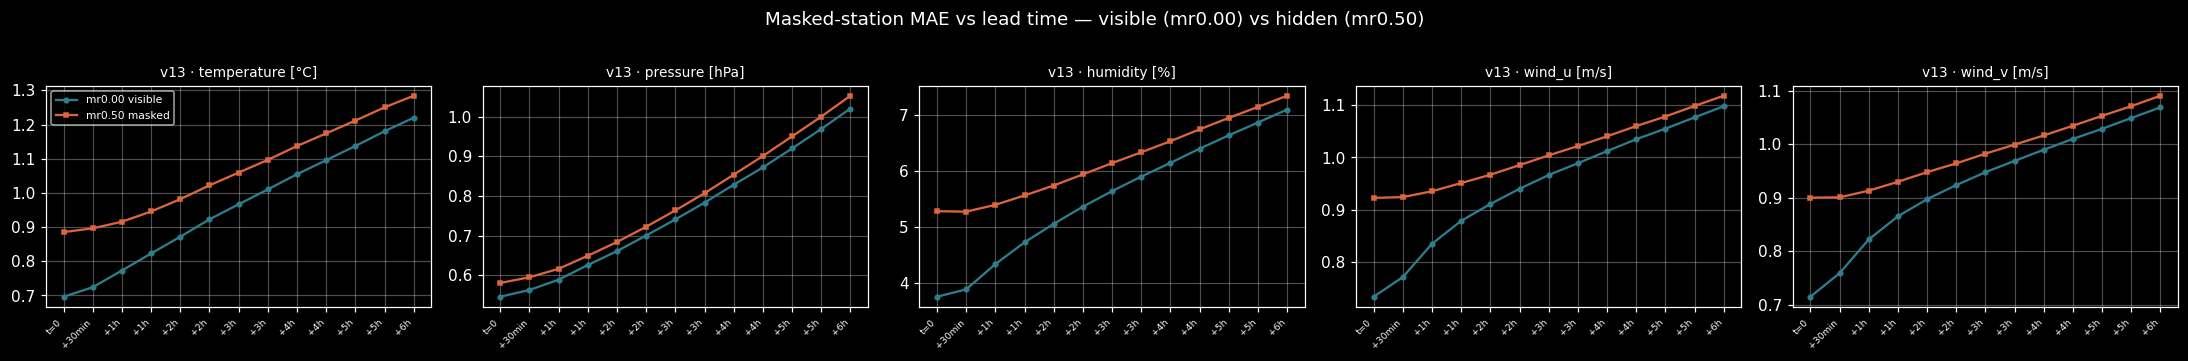

In [5]:
# ── Same comparison across lead time, per variable ───────────────────────────
runs2 = [r for r in RUNS if {"mr0.00","mr0.50"} <= set(RUNS[r])]
if runs2:
    fig, axes = plt.subplots(len(runs2), len(VARS), figsize=(4*len(VARS), 3.2*len(runs2)),
                             squeeze=False)
    for ri, run in enumerate(runs2):
        A5,C5 = AGG[(run,"mr0.50")]; A0,C0 = AGG[(run,"mr0.00")]
        for vi, v in enumerate(VARS):
            ax = axes[ri][vi]
            hid = M(A5, C5, "kv_m")[:,vi]
            vis = (M(A0, C0, "kv_m")[:,vi] if C0["kv_m"][:,vi].sum()
                   else M(A0, C0, "kv")[:,vi])
            ax.plot(range(len(GRID)), vis, "o-", color="#2E7D8C", lw=1.5, ms=3, label="mr0.00 visible")
            ax.plot(range(len(GRID)), hid, "s-", color="#D9663D", lw=1.5, ms=3, label="mr0.50 masked")
            ax.set_xticks(range(len(GRID))); ax.set_xticklabels(LEAD, rotation=45, ha="right", fontsize=6)
            ax.set_title(f"{run} · {v} [{ulab(v)}]", fontsize=9); ax.grid(alpha=0.3)
            if vi==0: ax.legend(fontsize=7)
    fig.suptitle(f"Masked-station {METRIC} vs lead time — visible (mr0.00) vs hidden (mr0.50)", y=1.01)
    plt.tight_layout(); plt.show()

## 2. Model comparison vs persistence

Per-variable error against lead time, in whichever metric `METRIC` is set to. The table reports **MAE and MSE skill together** — they can rank models differently, and that disagreement is informative. Transformers are shown at **mr0.50** (their trained
setting); the LSTM has no masking so it appears at mr0.00 — noted on the plot, since it
solves an easier problem. Persistence is the reference.

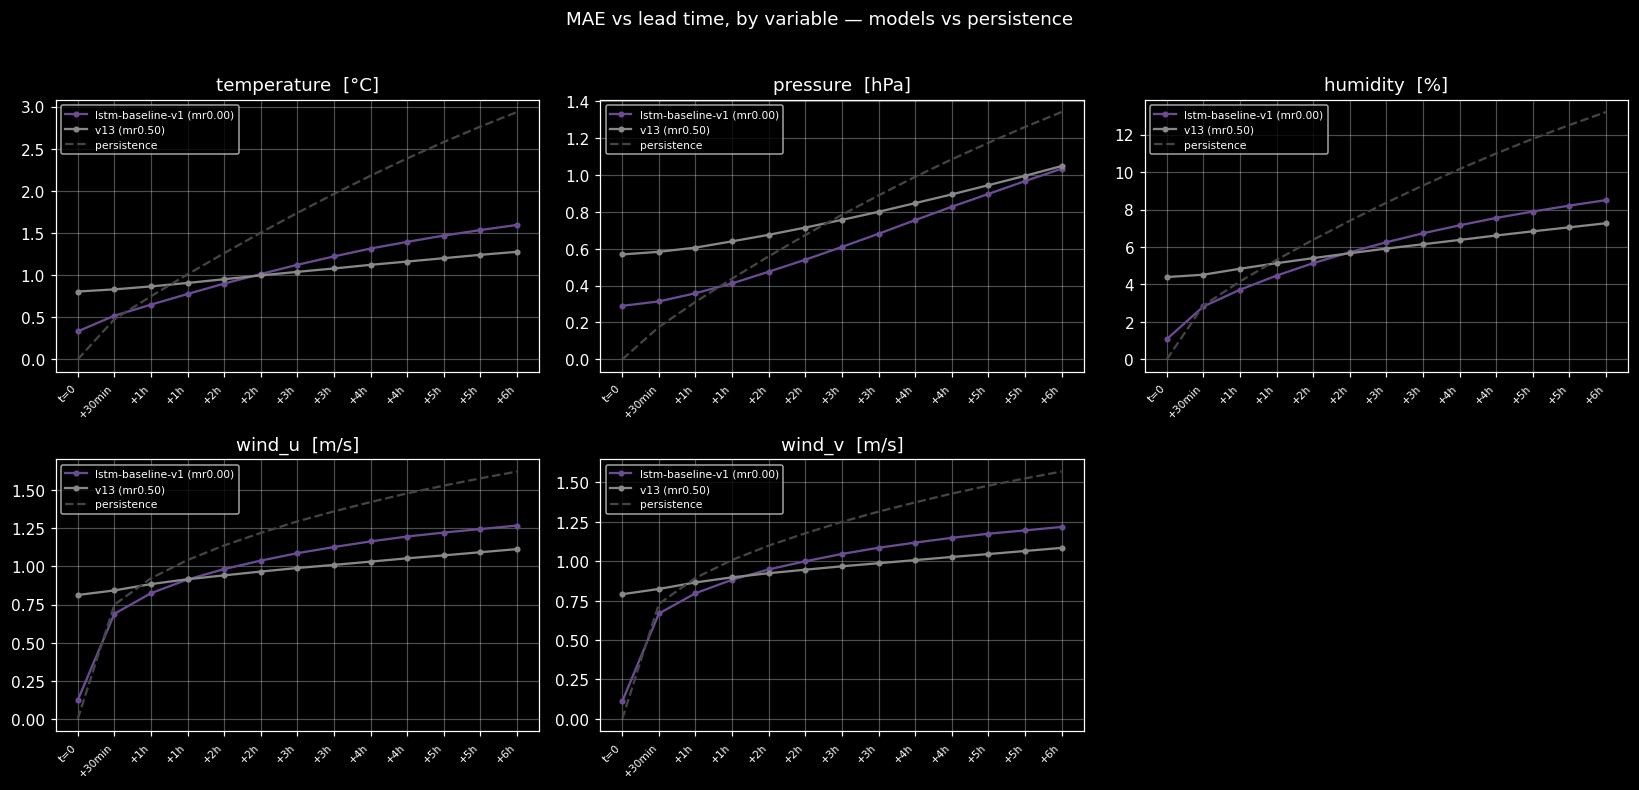

In [6]:
# ── Per-variable error vs lead time: models + persistence ───────────────────
# Plot follows METRIC (set in the config cell); the table below reports skill
# on BOTH MAE and MSE. Skill = 1 − model/persistence, so > 0 beats persistence.
# MSE-skill is the harsher test: it is dominated by the worst forecasts.
PREF = {}                       # run → mask ratio to display
for r in RUNS:
    PREF[r] = "mr0.50" if "mr0.50" in RUNS[r] else "mr0.00"

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (vi, v) in zip(axes.ravel(), enumerate(VARS)):
    for run, mr in PREF.items():
        A, C = AGG[(run, mr)]
        ax.plot(range(len(GRID)), M(A, C, "kv")[:, vi], "o-", ms=3, lw=1.5,
                color=COLORS.get(run, "#888"), label=f"{run} ({mr})")
    # persistence — identical across runs, so take the first
    A, C = AGG[list(AGG)[0]]
    ax.plot(range(len(GRID)), M(A, C, "kv_p", cnt_key="kv")[:, vi],
            "--", color="#444", lw=1.5, label="persistence")
    ax.set_xticks(range(len(GRID)))
    ax.set_xticklabels(LEAD, rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{v}  [{ulab(v)}]"); ax.grid(alpha=0.3); ax.legend(fontsize=7)
axes.ravel()[-1].axis("off")
fig.suptitle(f"{METRIC} vs lead time, by variable — models vs persistence", y=1.02)
plt.tight_layout(); plt.show()

# ── summary table: MAE and MSE side by side, with skill on each ─────────────
def _pool(A, C, key, sq, sl=slice(None), cnt_key=None):
    """Pool over horizons then reduce — never average per-horizon means."""
    num = A[key + ("_sq" if sq else "")][sl].sum()
    den = max(C[(cnt_key or key)][sl].sum(), 1)
    return num / den

rows = {}
Ap, Cp = AGG[list(AGG)[0]]
for run, mr in PREF.items():
    A, C = AGG[(run, mr)]
    for vi, v in enumerate(VARS):
        rec = {}
        for m, sq in (("MAE", False), ("MSE", True)):
            fc  = _pool(A,  C,  "kv",   sq, (slice(1, None), vi))
            per = _pool(Ap, Cp, "kv_p", sq, (slice(1, None), vi), cnt_key="kv")
            rec[f"{m} all"]         = _pool(A, C, "kv", sq, (slice(None), vi))
            rec[f"{m} Δ>0"]         = fc
            rec[f"persist {m} Δ>0"] = per
            rec[f"{m} skill"]       = 1 - fc / per if per else np.nan
        rec["RMSE Δ>0"] = np.sqrt(rec["MSE Δ>0"])
        rows[(f"{run} ({mr})", v)] = rec

t = pd.DataFrame(rows).T; t.index.names = ["model", "variable"]
t = t[["MAE all","MAE Δ>0","persist MAE Δ>0","MAE skill",
       "MSE all","MSE Δ>0","persist MSE Δ>0","MSE skill","RMSE Δ>0"]]
display(t.style
        .format({c_: ("{:+.3f}" if "skill" in c_ else "{:.3f}") for c_ in t.columns})
        .background_gradient(cmap="RdYlGn", subset=["MAE skill","MSE skill"],
                             vmin=-0.6, vmax=0.6)
        .set_caption("Skill > 0 beats persistence. MSE is in squared units and "
                     "weights large errors quadratically — where MAE-skill and "
                     "MSE-skill disagree, the model's error distribution differs "
                     "in shape from persistence's, not just in scale."))

## 3. Terrain — valley vs mountainous stations

Stations are split by altitude and slope (`ALT_THRESH`, `SLOPE_THRESH` at the top).
Complex terrain is where spatial interpolation is hardest, so this is the clearest test
of whether the models cope with the Alps.

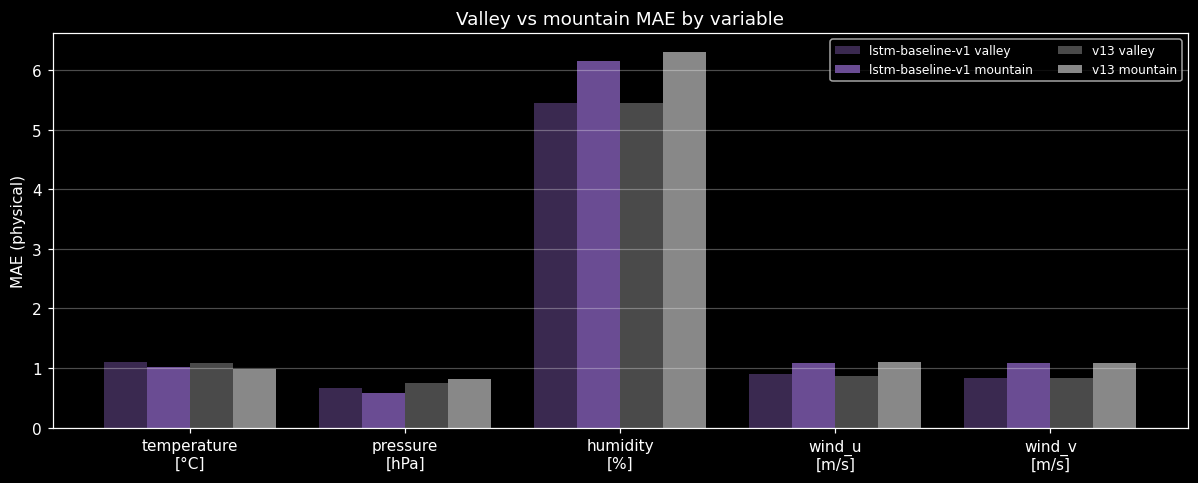

In [7]:
# ── Error by terrain class, per variable and model ───────────────────────────
rows = {}
for run, mr in PREF.items():
    A, C = AGG[(run, mr)]
    for vi, v in enumerate(VARS):
        for name, sel in [("valley", ~IS_MTN), ("mountain", IS_MTN)]:
            n   = max(C["sv"][sel, vi].sum(), 1)
            mae = A["sv"][sel, vi].sum() / n
            mse = A["sv_sq"][sel, vi].sum() / n
            rows[(f"{run} ({mr})", v, name)] = {
                "MAE": mae, "MSE": mse, "RMSE": np.sqrt(mse),
                "n_stations": int(sel.sum())}
t = pd.DataFrame(rows).T; t.index.names = ["model","variable","terrain"]

for m in ("MAE", "MSE"):
    piv = t[m].unstack("terrain").astype(float)
    piv["ratio mtn/valley"] = piv["mountain"] / piv["valley"]
    display(piv.style.format("{:.3f}")
            .background_gradient(cmap="OrRd", subset=["ratio mtn/valley"])
            .set_caption(f"{m} by terrain — ratio > 1 means the mountains are harder"
                         + ("  (squared units)" if m == "MSE" else "")))

x = np.arange(len(VARS)); nb_ = len(PREF); w = 0.8/max(nb_*2, 1)
fig, ax = plt.subplots(figsize=(11, 4.5))
for i, (run, mr) in enumerate(PREF.items()):
    A, C = AGG[(run, mr)]
    val, mtn = [], []
    for vi in range(len(VARS)):
        for sel, out in ((~IS_MTN, val), (IS_MTN, mtn)):
            n = max(C["sv"][sel, vi].sum(), 1)
            if METRIC == "MAE":   out.append(A["sv"][sel, vi].sum() / n)
            elif METRIC == "MSE": out.append(A["sv_sq"][sel, vi].sum() / n)
            else:                 out.append(np.sqrt(A["sv_sq"][sel, vi].sum() / n))
    ax.bar(x+(2*i-nb_+0.5)*w, val, w, color=COLORS.get(run,"#888"), alpha=0.55,
           label=f"{run} valley")
    ax.bar(x+(2*i-nb_+1.5)*w, mtn, w, color=COLORS.get(run,"#888"),
           label=f"{run} mountain")
ax.set_xticks(x); ax.set_xticklabels([f"{v}\n[{ulab(v)}]" for v in VARS])
ax.set_ylabel(f"{METRIC} (physical)")
ax.set_title(f"Valley vs mountain {METRIC} by variable")
ax.legend(fontsize=8, ncol=2); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Per-station performance by variable and season

Which stations the model handles well, and which it does not. Errors are normalised by
each station's own training σ (**nMAE**) so stations with different natural variability
are comparable — a raw MAE would simply rank the windiest sites worst.

In [8]:
# ── Per-station normalised error by variable, best / worst ──────────────────
# Normalised by the station's own training σ so stations are comparable:
#   nMAE, nRMSE  divide by σ      nMSE  divides by σ²   (units must match)
RUN_INSPECT = "v9" if "v9" in RUNS else list(RUNS)[0]      # ← change to inspect another
MR = PREF[RUN_INSPECT]
A, C = AGG[(RUN_INSPECT, MR)]

_n = np.maximum(C["sv"], 1)
_phys = {"MAE": A["sv"]/_n, "MSE": A["sv_sq"]/_n, "RMSE": np.sqrt(A["sv_sq"]/_n)}
_norm = {"MAE": _phys["MAE"]/STD, "MSE": _phys["MSE"]/STD**2, "RMSE": _phys["RMSE"]/STD}

nrm_tbl = pd.DataFrame(_norm[METRIC], index=STN, columns=VARS)
nrm_tbl["mean"] = nrm_tbl.mean(axis=1)
nrm_tbl["terrain"] = np.where(IS_MTN, "mountain", "valley")

print(f"{RUN_INSPECT} ({MR}) — per-station n{METRIC} "
      f"(error ÷ station σ{'²' if METRIC=='MSE' else ''})")
display(nrm_tbl.nsmallest(10, "mean").style.format({c_:"{:.3f}" for c_ in VARS+["mean"]})
        .set_caption(f"10 BEST stations (n{METRIC})"))
display(nrm_tbl.nlargest(10, "mean").style.format({c_:"{:.3f}" for c_ in VARS+["mean"]})
        .set_caption(f"10 WORST stations (n{METRIC})"))

# Do MAE and MSE agree on who the worst stations are? If not, those stations
# are hurt by occasional large errors rather than consistent mediocrity.
_wm = pd.DataFrame(_norm["MAE"], index=STN, columns=VARS).mean(axis=1).nlargest(15).index
_ws = pd.DataFrame(_norm["MSE"], index=STN, columns=VARS).mean(axis=1).nlargest(15).index
_only_mse = [s for s in _ws if s not in _wm]
print(f"\nWorst-15 by nMAE vs nMSE: {len(set(_wm) & set(_ws))}/15 in common.")
if _only_mse:
    print(f"  Bad on MSE only (large-error driven): {', '.join(_only_mse)}")

lstm-baseline-v1 (mr0.00) — per-station nMAE (error ÷ station σ)


,temperature,pressure,humidity,wind_u,wind_v,mean,terrain
LAC,0.127,0.000,0.329,0.000,0.000,0.091,valley
ILZ,0.128,0.093,0.262,0.000,0.000,0.096,valley
GRC,0.126,0.080,0.289,0.000,0.000,0.099,mountain
PSI,0.146,0.088,0.276,0.000,0.000,0.102,valley
PRE,0.000,0.000,0.000,0.389,0.368,0.151,valley
STK,0.000,0.091,0.000,0.390,0.420,0.180,valley
AEG,0.000,0.000,0.000,0.561,0.484,0.209,valley
MTR,0.103,0.068,0.289,0.340,0.314,0.223,mountain
QUI,0.000,0.097,0.000,0.481,0.572,0.230,mountain
JUN,0.117,0.062,0.303,0.343,0.337,0.232,mountain


,temperature,pressure,humidity,wind_u,wind_v,mean,terrain
BIZ,0.145,0.093,0.284,0.627,0.704,0.371,valley
LAE,0.138,0.093,0.332,0.491,0.729,0.357,valley
ARH,0.148,0.096,0.383,0.597,0.548,0.354,valley
INT,0.133,0.096,0.336,0.584,0.568,0.343,valley
GES,0.125,0.053,0.334,0.614,0.588,0.343,mountain
MOA,0.152,0.092,0.305,0.620,0.535,0.341,valley
CHZ,0.127,0.093,0.308,0.581,0.584,0.339,valley
MUB,0.133,0.089,0.296,0.402,0.748,0.334,valley
THU,0.146,0.092,0.318,0.526,0.584,0.333,valley
ARO,0.127,0.076,0.297,0.606,0.559,0.333,mountain



Worst-15 by nMAE vs nMSE: 12/15 in common.
  Bad on MSE only (large-error driven): VLS, SCU, GIH


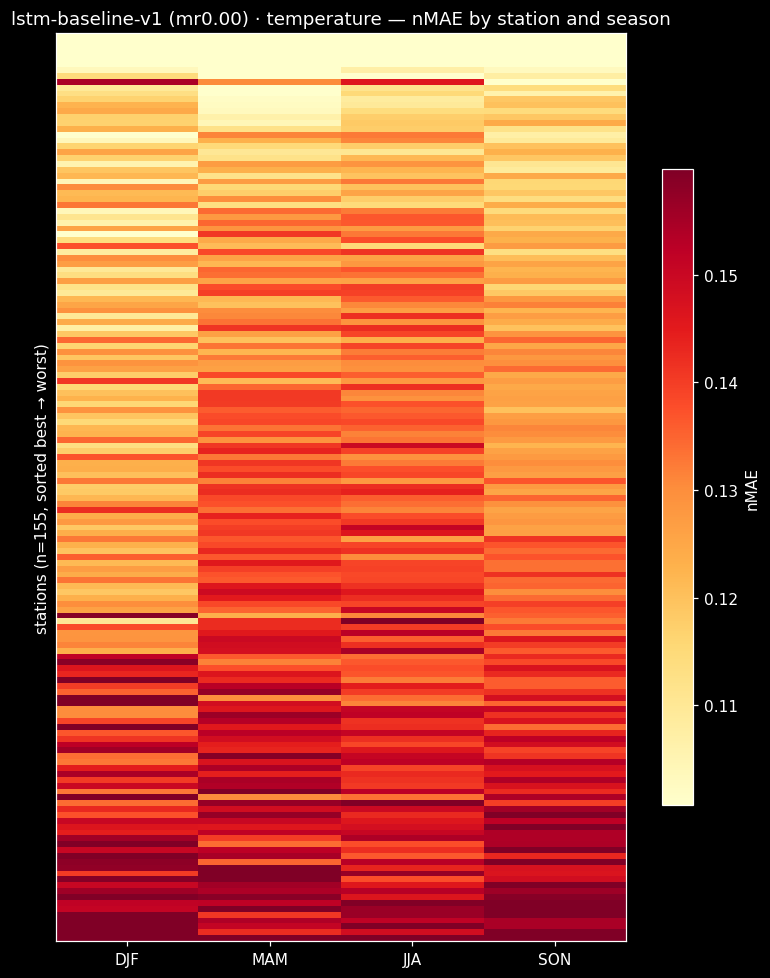

,DJF,MAM,JJA,SON
terrain,,,,
mountain,0.132,0.125,0.129,0.128
valley,0.122,0.137,0.134,0.127


,DJF,MAM,JJA,SON,worst season,terrain
ANT,0.196,0.142,0.148,0.171,DJF,mountain
SAM,0.179,0.134,0.138,0.154,DJF,mountain
BUF,0.177,0.130,0.133,0.154,DJF,mountain
BRL,0.177,0.168,0.173,0.187,SON,mountain
ROB,0.176,0.154,0.152,0.155,DJF,mountain
BIA,0.175,0.151,0.165,0.155,DJF,mountain
SBO,0.172,0.155,0.136,0.143,DJF,valley
BIV,0.165,0.141,0.156,0.171,SON,mountain
SIA,0.162,0.130,0.134,0.148,DJF,mountain
MAG,0.162,0.143,0.132,0.136,DJF,valley


In [9]:
# ── Station × season heatmap for one variable ────────────────────────────────
SEASON_VAR = "temperature"      # ← change variable
vi = VARS.index(SEASON_VAR)
_ns_n = np.maximum(C["svs"][:,vi,:], 1)
if METRIC == "MAE":
    ns = (A["svs"][:,vi,:] / _ns_n) / STD[:,vi:vi+1]
elif METRIC == "MSE":
    ns = (A["svs_sq"][:,vi,:] / _ns_n) / (STD[:,vi:vi+1]**2)
else:
    ns = np.sqrt(A["svs_sq"][:,vi,:] / _ns_n) / STD[:,vi:vi+1]   # (N,4) normalised
order = np.argsort(np.nanmean(ns, axis=1))

fig, ax = plt.subplots(figsize=(7, 9))
im = ax.imshow(ns[order], aspect="auto", cmap="YlOrRd",
               vmin=np.nanpercentile(ns,5), vmax=np.nanpercentile(ns,95))
ax.set_xticks(range(4)); ax.set_xticklabels(SEASONS)
ax.set_yticks([]); ax.set_ylabel(f"stations (n={N}, sorted best → worst)")
ax.set_title(f"{RUN_INSPECT} ({MR}) · {SEASON_VAR} — n{METRIC} by station and season")
plt.colorbar(im, ax=ax, label=f"n{METRIC}", shrink=0.7)
plt.tight_layout(); plt.show()

seas_tbl = pd.DataFrame(ns, index=STN, columns=SEASONS)
seas_tbl["worst season"] = seas_tbl[SEASONS].idxmax(axis=1)
seas_tbl["terrain"] = np.where(IS_MTN, "mountain", "valley")
display(seas_tbl.groupby("terrain")[SEASONS].mean().style.format("{:.3f}")
        .set_caption(f"{SEASON_VAR} n{METRIC} by season and terrain"))
display(seas_tbl.nlargest(12, SEASONS).style.format({s:"{:.3f}" for s in SEASONS})
        .set_caption(f"Stations struggling most on {SEASON_VAR}"))

## 5. Predicted uncertainty — is σ trustworthy?

Runs trained with the heteroscedastic Gaussian NLL (**v9**) carry a second head,
`log_var_head`, that predicts log σ² for every (horizon, station, variable).
That head was previously discarded at evaluation time; the dumps now contain it
as `log_var`, so this section can run.

Everything here is derived from the standardised residual

$$z \;=\; \frac{\hat{y} - y}{\sigma}, \qquad \sigma = \exp(\tfrac{1}{2}\log\sigma^2)$$

which is scale-free, so σ and the error are compared in the same normalised
space before being converted to physical units for reporting.

A σ can fail in two independent ways, and they need separating:

| | question | diagnostic | reading |
|---|---|---|---|
| **Calibration** | is σ the right *size*? | RMS(z), coverage | RMS(z) > 1 → overconfident (σ too small) |
| **Discrimination** | does σ *vary* with the actual difficulty? | spread–skill, rank correlation | flat curve → σ is a constant, useless |

A model can be perfectly calibrated on average and still useless: if it emits the
same σ everywhere, RMS(z) = 1 but the uncertainty carries no information. The
rank correlation is the number that catches this.

Runs without the NLL head (v11 Huber, LSTM) are skipped automatically.

In [10]:
# ─UNCERTAINTY─ Stream σ from every dump that carries an NLL head ────────────
import torch

Z_LEVELS = {"50%": 0.6745, "90%": 1.6449, "95%": 1.9600}   # two-sided Gaussian
SUB_FRAC = 0.002          # thinning rate for the spread-skill / residual sample
_rng     = np.random.default_rng(0)

def aggregate_sigma(path):
    """Full-pass sums for calibration curves + a thinned (σ, |err|, z) sample."""
    d = torch.load(path, map_location="cpu", weights_only=False)
    if "log_var" not in d:
        del d
        return None
    P, T, M, LV = d["preds"], d["targets"], d["masks"], d["log_var"]
    MI = d.get("masked_idx")
    Mw, K, Nst, V = P.shape

    a = {k: np.zeros(sh) for k, sh in {
        "sig":(K,V), "e2":(K,V), "z1":(K,V), "z2":(K,V), "n":(K,V),
        "cov":(K,V,len(Z_LEVELS)),
        "sig_m":(V,), "e2_m":(V,), "n_m":(V,),     # masked stations
        "sig_v":(V,), "e2_v":(V,), "n_v":(V,),     # visible stations
    }.items()}
    sub = {k: [] for k in ("sig","err","z","v")}

    for lo in range(0, Mw, CHUNK):
        hi = min(lo+CHUNK, Mw)
        p  = P[lo:hi].numpy(); t = T[lo:hi,:,:,:V].numpy()
        m  = M[lo:hi,:,:,:V].numpy() > 0.5
        sg = np.exp(0.5 * LV[lo:hi].numpy())                # σ, normalised units
        r  = p - t                                          # signed residual, normalised
        z  = r / np.clip(sg, 1e-6, None)
        sgp = sg * STD[None,None,:,:]                       # σ, physical
        ep  = np.abs(r) * STD[None,None,:,:]                # |err|, physical

        a["sig"] += (sgp * m).sum(axis=(0,2))
        a["e2"]  += ((ep**2) * m).sum(axis=(0,2))
        a["z1"]  += (z * m).sum(axis=(0,2))
        a["z2"]  += ((z**2) * m).sum(axis=(0,2))
        a["n"]   += m.sum(axis=(0,2))
        for j, thr in enumerate(Z_LEVELS.values()):
            a["cov"][:,:,j] += ((np.abs(z) < thr) & m).sum(axis=(0,2))

        if MI is not None and MI.shape[1] > 0:              # masked vs visible split
            sel = np.zeros((hi-lo, Nst), bool)
            np.put_along_axis(sel, MI[lo:hi].numpy(), True, axis=1)
            sm = m &  sel[:,None,:,None]
            sv = m & ~sel[:,None,:,None]
            for tag, w in (("_m", sm), ("_v", sv)):
                a["sig"+tag] += (sgp * w).sum(axis=(0,1,2))
                a["e2"+tag]  += ((ep**2) * w).sum(axis=(0,1,2))
                a["n"+tag]   += w.sum(axis=(0,1,2))

        take = m & (_rng.random(m.shape) < SUB_FRAC)        # thinned sample
        if take.any():
            sub["sig"].append(sgp[take]); sub["err"].append(ep[take])
            sub["z"].append(z[take]);     sub["v"].append(np.nonzero(take)[3])
        del p, t, m, sg, r, z, sgp, ep, take

    del d, P, T, M, LV
    return a, {k: np.concatenate(v) for k, v in sub.items()}

SIG = {}
for run, mrs in RUNS.items():
    for mr, path in sorted(mrs.items()):
        out = aggregate_sigma(path)
        if out is None:
            print(f"  {run:20s} {mr}   no log_var — point-prediction model, skipped")
        else:
            SIG[(run, mr)] = out
            print(f"  {run:20s} {mr}   σ loaded   (sample {len(out[1]['sig']):,} values)")

if not SIG:
    print("\nNo run carries a predicted σ.")
    print("Re-run test.py on the v9 checkpoint — the NLL head is auto-detected from")
    print("the state_dict, and collect_predictions() now saves log_var.")

  lstm-baseline-v1     mr0.00   no log_var — point-prediction model, skipped
  v13                  mr0.00   no log_var — point-prediction model, skipped
  v13                  mr0.50   no log_var — point-prediction model, skipped

No run carries a predicted σ.
Re-run test.py on the v9 checkpoint — the NLL head is auto-detected from
the state_dict, and collect_predictions() now saves log_var.


### 5a. Calibration — is σ the right size?

`ratio = mean σ / RMSE` and `RMS(z)` say the same thing from two directions.
`RMS(z) = 1` is perfect; **above 1 the model is overconfident**. `mean(z)` isolates
systematic bias (the warm bias in temperature should show up here). Coverage is
the fraction of observations falling inside the nominal interval — a calibrated
Gaussian gives 50 / 90 / 95 %.

Note that `ratio` is only indicative: when σ varies across stations, mean σ < RMS σ by Jensen's inequality, so a perfectly calibrated model still lands near 0.90. **`RMS z` is the metric to read** — it is exact.

`rank_corr` is Spearman's ρ between σ and |error|: **this is the number that
decides whether σ is worth anything at all.** ρ ≈ 0 means σ is effectively a
constant and carries no skill, however well calibrated it is.

In [11]:
# ─UNCERTAINTY─ Calibration table ────────────────────────────────────────────
if not SIG:
    print("No loaded run carries a predicted σ — §5a skipped.")
    print()
    print("This section needs a checkpoint trained with the heteroscedastic")
    print("Gaussian NLL (v9). To populate it:")
    print("  1. src/scripts/run_test_cloud.sh  with RUN_NAME=\"v9\"")
    print("  2. re-run §5's first cell")
    print("test.py auto-detects log_var_head from the state_dict, and")
    print("collect_predictions() saves log_var alongside the predictions.")
else:
    def spearman(x, y):
        """Rank correlation without a scipy dependency (ties broken arbitrarily)."""
        rx = np.argsort(np.argsort(x)).astype(float)
        ry = np.argsort(np.argsort(y)).astype(float)
        rx -= rx.mean(); ry -= ry.mean()
        den = np.sqrt((rx**2).sum() * (ry**2).sum())
        return float((rx*ry).sum()/den) if den > 0 else np.nan

    rows = []
    for (run, mr), (a, sb) in SIG.items():
        for v, name in enumerate(VARS):
            n = max(a["n"][:,v].sum(), 1.0)
            cov = a["cov"][:,v,:].sum(axis=0)/n
            s = sb["v"] == v
            rows.append({
                "run": f"{run} {mr}", "variable": name, "unit": UNITS[name],
                "mean σ":   a["sig"][:,v].sum()/n,
                "RMSE":     np.sqrt(a["e2"][:,v].sum()/n),
                "ratio":    (a["sig"][:,v].sum()/n) / max(np.sqrt(a["e2"][:,v].sum()/n), 1e-9),
                "mean z":   a["z1"][:,v].sum()/n,
                "RMS z":    np.sqrt(a["z2"][:,v].sum()/n),
                **{f"cov {k}": cov[j] for j, k in enumerate(Z_LEVELS)},
                "rank_corr": spearman(sb["sig"][s], sb["err"][s]),
            })
    cal = pd.DataFrame(rows)

    def _hl_ratio(s):   # 1.0 is perfect
        return ["background-color:#FBE9E7" if abs(x-1) > 0.25 else "" for x in s]

    display(cal.style
            .format({"mean σ":"{:.3f}", "RMSE":"{:.3f}", "ratio":"{:.2f}",
                     "mean z":"{:+.3f}", "RMS z":"{:.2f}", "rank_corr":"{:.3f}",
                     **{f"cov {k}":"{:.1%}" for k in Z_LEVELS}})
            .apply(_hl_ratio, subset=["ratio"])
            .set_caption("Calibration of the predicted σ — ratio and RMS z should be 1.00"))

    print("\nReading:")
    print("  RMS z > 1     σ too small — the model is OVERCONFIDENT")
    print("  RMS z < 1     σ too large — underconfident, predictions are hedged")
    print("  |mean z| > 0  systematic bias, not a spread problem")
    print("  rank_corr     0.0 = σ is a constant (no skill);  >0.3 = genuinely informative")

No loaded run carries a predicted σ — §5a skipped.

This section needs a checkpoint trained with the heteroscedastic
Gaussian NLL (v9). To populate it:
  1. src/scripts/run_test_cloud.sh  with RUN_NAME="v9"
  2. re-run §5's first cell
test.py auto-detects log_var_head from the state_dict, and
collect_predictions() saves log_var alongside the predictions.


### 5b. Spread–skill and the residual distribution

**Top row** — the σ values are split into deciles; within each decile the
observed RMSE is plotted against the mean predicted σ. A useful uncertainty
estimate climbs monotonically along the dashed 1:1 line. A *flat* curve is the
failure mode to look for: it means σ varies but the error does not follow it.
A curve that is monotone but sits below the diagonal is informative yet
mis-scaled — fixable with a single multiplicative recalibration constant.

**Bottom row** — the distribution of z against the standard normal the NLL
assumes. Too wide → overconfident; heavy tails → the Gaussian is the wrong
family for that variable (expect this for wind).

In [12]:
# ─UNCERTAINTY─ Spread-skill + standardised-residual histograms ──────────────
if not SIG:
    print("No loaded run carries a predicted σ — §5b skipped.")
    print()
    print("This section needs a checkpoint trained with the heteroscedastic")
    print("Gaussian NLL (v9). To populate it:")
    print("  1. src/scripts/run_test_cloud.sh  with RUN_NAME=\"v9\"")
    print("  2. re-run §5's first cell")
    print("test.py auto-detects log_var_head from the state_dict, and")
    print("collect_predictions() saves log_var alongside the predictions.")
else:
    KEY = (next((k for k in SIG if k[1] == "mr0.50"), None) or next(iter(SIG)))
    a, sb = SIG[KEY]
    print(f"Run shown: {KEY[0]} {KEY[1]}   (sample size {len(sb['sig']):,})")

    NB_ = 10
    fig, axes = plt.subplots(2, len(VARS), figsize=(3.05*len(VARS), 6.3))
    col = COLORS.get(KEY[0], "#2E7D8C")
    ss_rows = []
    for v, name in enumerate(VARS):
        s  = sb["v"] == v
        sg, er, zz = sb["sig"][s], sb["err"][s], sb["z"][s]

        # ── decile spread-skill ──
        ax = axes[0, v]
        if s.sum() > NB_ * 20:
            edges = np.quantile(sg, np.linspace(0, 1, NB_+1))
            b  = np.clip(np.digitize(sg, edges[1:-1]), 0, NB_-1)
            ms = np.array([sg[b == i].mean()                for i in range(NB_)])
            mr = np.array([np.sqrt((er[b == i]**2).mean())  for i in range(NB_)])
            lim = [0, max(ms.max(), mr.max())*1.08]
            ax.plot(lim, lim, "--", color="#999", lw=1)
            ax.plot(ms, mr, "o-", color=col, ms=4.5, lw=1.4)
            ax.set_xlim(lim); ax.set_ylim(lim)
            ss_rows.append({"variable": name, "unit": UNITS[name],
                            "σ decile 1": ms[0],  "RMSE decile 1": mr[0],
                            "σ decile 10": ms[-1], "RMSE decile 10": mr[-1],
                            "RMSE spread ×": mr[-1]/max(mr[0], 1e-9)})
        ax.set_title(f"{name} ({UNITS[name]})", fontsize=9.5)
        ax.set_xlabel("predicted σ, decile mean", fontsize=8.5)
        if v == 0: ax.set_ylabel("observed RMSE", fontsize=8.5)
        ax.tick_params(labelsize=8); ax.grid(alpha=0.3)

        # ── standardised residuals vs N(0,1) ──
        ax2 = axes[1, v]
        zc = zz[np.abs(zz) < 6]
        ax2.hist(zc, bins=60, density=True, color="#BBD3DD", edgecolor="none")
        xs = np.linspace(-6, 6, 300)
        ax2.plot(xs, np.exp(-xs**2/2)/np.sqrt(2*np.pi), color="#B23A3A", lw=1.3)
        ax2.set_xlabel("z = (pred − obs) / σ", fontsize=8.5)
        if v == 0: ax2.set_ylabel("density", fontsize=8.5)
        ax2.tick_params(labelsize=8); ax2.grid(alpha=0.3)
        ax2.text(0.03, 0.93, f"RMS {np.sqrt((zz**2).mean()):.2f}",
                 transform=ax2.transAxes, fontsize=8, va="top")

    axes[0,0].plot([], [], "--", color="#999", label="perfect (1:1)")
    axes[0,0].legend(fontsize=7.5, loc="upper left")
    fig.suptitle(f"Spread–skill (top) and standardised residuals (bottom) — "
                 f"{KEY[0]} {KEY[1]}", fontsize=11)
    plt.tight_layout(); plt.show()

    if ss_rows:
        display(pd.DataFrame(ss_rows).style
                .format({c: "{:.3f}" for c in
                         ["σ decile 1","RMSE decile 1","σ decile 10","RMSE decile 10"]}
                        | {"RMSE spread ×": "{:.2f}"})
                .set_caption("Lowest vs highest σ decile — 'RMSE spread ×' is how much "
                             "worse the model actually is where it says it is unsure "
                             "(1.0 = σ carries no information)"))

No loaded run carries a predicted σ — §5b skipped.

This section needs a checkpoint trained with the heteroscedastic
Gaussian NLL (v9). To populate it:
  1. src/scripts/run_test_cloud.sh  with RUN_NAME="v9"
  2. re-run §5's first cell
test.py auto-detects log_var_head from the state_dict, and
collect_predictions() saves log_var alongside the predictions.


### 5c. Does σ react to lead time and to masking?

Two sanity checks on whether σ responds to the things that genuinely make the
problem harder.

**Lead time** — the error grows from t=0 to +6 h, so σ must grow with it. Solid
lines are mean σ, dashed are the realised RMSE; the gap between them *is* the
mis-calibration, drawn horizon by horizon. A flat σ line under a rising RMSE
line means the uncertainty head learned a global constant.

**Masking** — at mr0.50 half the stations are hidden from the encoder, and the
model is measurably worse on them. If σ is doing its job it should be larger on
the masked stations by roughly the same factor as the error is.

In [13]:
# ─UNCERTAINTY─ σ vs lead time, and masked vs visible ────────────────────────
if not SIG:
    print("No loaded run carries a predicted σ — §5c skipped.")
    print()
    print("This section needs a checkpoint trained with the heteroscedastic")
    print("Gaussian NLL (v9). To populate it:")
    print("  1. src/scripts/run_test_cloud.sh  with RUN_NAME=\"v9\"")
    print("  2. re-run §5's first cell")
    print("test.py auto-detects log_var_head from the state_dict, and")
    print("collect_predictions() saves log_var alongside the predictions.")
else:
    fig, axes = plt.subplots(1, len(VARS), figsize=(3.05*len(VARS), 3.1), squeeze=False)
    for v, name in enumerate(VARS):
        ax = axes[0, v]
        for (run, mr), (a, _) in SIG.items():
            n = np.clip(a["n"][:, v], 1, None)
            c = COLORS.get(run, "#2E7D8C")
            ax.plot(range(len(GRID)), a["sig"][:, v]/n, "-o", ms=3.2, lw=1.4,
                    color=c, label=f"σ  {run} {mr}")
            ax.plot(range(len(GRID)), np.sqrt(a["e2"][:, v]/n), "--s", ms=3.2, lw=1.2,
                    color=c, alpha=0.55, label=f"RMSE  {run} {mr}")
        ax.set_title(f"{name} ({UNITS[name]})", fontsize=9.5)
        ax.set_xticks(range(0, len(GRID), 3))
        ax.set_xticklabels([LEAD[i] for i in range(0, len(GRID), 3)], fontsize=7.5, rotation=45)
        ax.tick_params(labelsize=8); ax.grid(alpha=0.3)
        if v == 0:
            ax.set_ylabel("physical units", fontsize=8.5)
            ax.legend(fontsize=6.8, loc="upper left")
    fig.suptitle("Predicted σ (solid) vs realised RMSE (dashed) by lead time — "
                 "the gap is the mis-calibration", fontsize=11)
    plt.tight_layout(); plt.show()

    # ── masked vs visible ────────────────────────────────────────────────────────
    rows = []
    for (run, mr), (a, _) in SIG.items():
        if a["n_m"].sum() == 0:
            continue
        for v, name in enumerate(VARS):
            nm, nv = max(a["n_m"][v], 1), max(a["n_v"][v], 1)
            sm, sv = a["sig_m"][v]/nm, a["sig_v"][v]/nv
            em, ev = np.sqrt(a["e2_m"][v]/nm), np.sqrt(a["e2_v"][v]/nv)
            rows.append({"run": f"{run} {mr}", "variable": name, "unit": UNITS[name],
                         "σ visible": sv, "σ masked": sm, "σ ratio": sm/max(sv, 1e-9),
                         "RMSE visible": ev, "RMSE masked": em,
                         "RMSE ratio": em/max(ev, 1e-9)})
    if rows:
        mv = pd.DataFrame(rows)
        mv["σ tracks error"] = mv["σ ratio"] / mv["RMSE ratio"]
        display(mv.style
                .format({c: "{:.3f}" for c in ["σ visible","σ masked","RMSE visible","RMSE masked"]}
                        | {c: "{:.2f}" for c in ["σ ratio","RMSE ratio","σ tracks error"]})
                .background_gradient(cmap="RdYlGn_r", subset=["σ tracks error"], vmin=0.5, vmax=1.5)
                .set_caption("Masked vs visible stations. 'σ tracks error' = 1.00 means σ "
                             "inflates on hidden stations by exactly the amount the error does; "
                             "< 1 means the model does not realise it is flying blind."))
    else:
        print("No mr0.50 dump with masked_idx — masked/visible split unavailable.")

No loaded run carries a predicted σ — §5c skipped.

This section needs a checkpoint trained with the heteroscedastic
Gaussian NLL (v9). To populate it:
  1. src/scripts/run_test_cloud.sh  with RUN_NAME="v9"
  2. re-run §5's first cell
test.py auto-detects log_var_head from the state_dict, and
collect_predictions() saves log_var alongside the predictions.


### 5d. What σ would be worth in practice

If σ turns out to be informative (`rank_corr` clearly above zero, monotone
spread–skill), it earns two concrete uses in the write-up:

1. **A recalibration constant.** Fit one scalar per variable, `c = RMS(z)`, and
   report `σ' = σ / c`. This costs nothing, needs no retraining, and fixes the
   size problem while preserving the ranking. Report calibration before and after.
2. **Selective prediction.** Withhold the most-uncertain *x* % of predictions and
   recompute the error on what remains. If the curve falls steeply the model can
   flag its own failures — a far more useful claim to a forecaster than a single
   headline RMSE.

The cell below computes (2), which doubles as the most legible summary of
whether σ carries any information at all.

In [14]:
# ─UNCERTAINTY─ Selective prediction: error after withholding the least-certain
if not SIG:
    print("No loaded run carries a predicted σ — §5d skipped.")
    print()
    print("This section needs a checkpoint trained with the heteroscedastic")
    print("Gaussian NLL (v9). To populate it:")
    print("  1. src/scripts/run_test_cloud.sh  with RUN_NAME=\"v9\"")
    print("  2. re-run §5's first cell")
    print("test.py auto-detects log_var_head from the state_dict, and")
    print("collect_predictions() saves log_var alongside the predictions.")
else:
    a, sb = SIG[KEY]
    FRACS = np.array([0.0, 0.05, 0.10, 0.20, 0.30, 0.50])

    fig, ax = plt.subplots(figsize=(7.2, 4.0))
    rows = []
    for v, name in enumerate(VARS):
        s = sb["v"] == v
        sg, er = sb["sig"][s], sb["err"][s]
        if s.sum() < 200:
            continue
        order = np.argsort(sg)                       # most certain first
        e_sorted = er[order]
        base = np.sqrt((e_sorted**2).mean())
        curve = []
        for f in FRACS:
            k = int(round(len(e_sorted) * (1 - f)))
            curve.append(np.sqrt((e_sorted[:k]**2).mean()) if k > 10 else np.nan)
        curve = np.array(curve)
        ax.plot(FRACS*100, curve/base, "-o", ms=4, label=name)
        rows.append({"variable": name, "unit": UNITS[name], "RMSE (all)": base,
                     "RMSE (drop 10%)": curve[2], "RMSE (drop 30%)": curve[4],
                     "reduction @30%": 1 - curve[4]/base})

    ax.axhline(1.0, color="#999", ls="--", lw=1)
    ax.set_xlabel("% of most-uncertain predictions withheld")
    ax.set_ylabel("RMSE relative to keeping everything")
    ax.set_title(f"Selective prediction — {KEY[0]} {KEY[1]}\n"
                 "a flat line means σ cannot identify the model's own bad forecasts",
                 fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    if rows:
        display(pd.DataFrame(rows).style
                .format({"RMSE (all)":"{:.3f}", "RMSE (drop 10%)":"{:.3f}",
                         "RMSE (drop 30%)":"{:.3f}", "reduction @30%":"{:.1%}"})
                .set_caption("Withholding the least-certain forecasts. A large reduction "
                             "means σ is genuinely diagnostic; ~0 % means it is noise."))

No loaded run carries a predicted σ — §5d skipped.

This section needs a checkpoint trained with the heteroscedastic
Gaussian NLL (v9). To populate it:
  1. src/scripts/run_test_cloud.sh  with RUN_NAME="v9"
  2. re-run §5's first cell
test.py auto-detects log_var_head from the state_dict, and
collect_predictions() saves log_var alongside the predictions.
